# Load the data ﬁle and explore the data, showing size, data descriptions, data distributions with boxplot, and correlation between columns

In [41]:
import pandas as pd

df = pd.read_csv('written-test-2025-06-30-exam-2.csv')

In [42]:
df.info()
print('----------------------------------------------------------------')
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X00     1000 non-null   float64
 1   X01     1000 non-null   float64
 2   X02     1000 non-null   float64
 3   X03     1000 non-null   float64
 4   X04     1000 non-null   float64
 5   X05     1000 non-null   float64
 6   X06     1000 non-null   float64
 7   X07     1000 non-null   float64
 8   X08     1000 non-null   float64
 9   X09     1000 non-null   float64
 10  y       1000 non-null   float64
dtypes: float64(11)
memory usage: 86.1 KB
----------------------------------------------------------------


,X00,X01,X02,X03,X04,X05,X06,X07,X08,X09,y
count,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.000127,0.000297,-0.000421,3.378287e-01,2.521912e-01,0.000364,-0.000191,0.000553,0.000130,0.000524,0.437747
std,0.023475,0.018878,0.019124,2.952473e-01,2.877240e-01,0.017402,0.019349,0.017783,0.018999,0.025391,2.407762
min,-0.074550,-0.055749,-0.063489,9.531015e-07,6.913766e-10,-0.054694,-0.058531,-0.054578,-0.062925,-0.073059,-6.609545
25%,-0.015763,-0.012357,-0.013722,6.778294e-02,1.552023e-02,-0.011251,-0.013393,-0.011797,-0.012001,-0.018202,-1.200759
50%,0.000446,0.000269,-0.000891,2.638645e-01,1.218160e-01,0.000675,-0.000333,0.000422,-0.000858,-0.000219,0.336424
75%,0.015529,0.013924,0.012571,5.712697e-01,4.295876e-01,0.012217,0.012797,0.012697,0.012722,0.018642,2.175038
max,0.079599,0.073114,0.052593,9.996939e-01,9.988956e-01,0.053673,0.051803,0.049480,0.061867,0.081461,7.915506


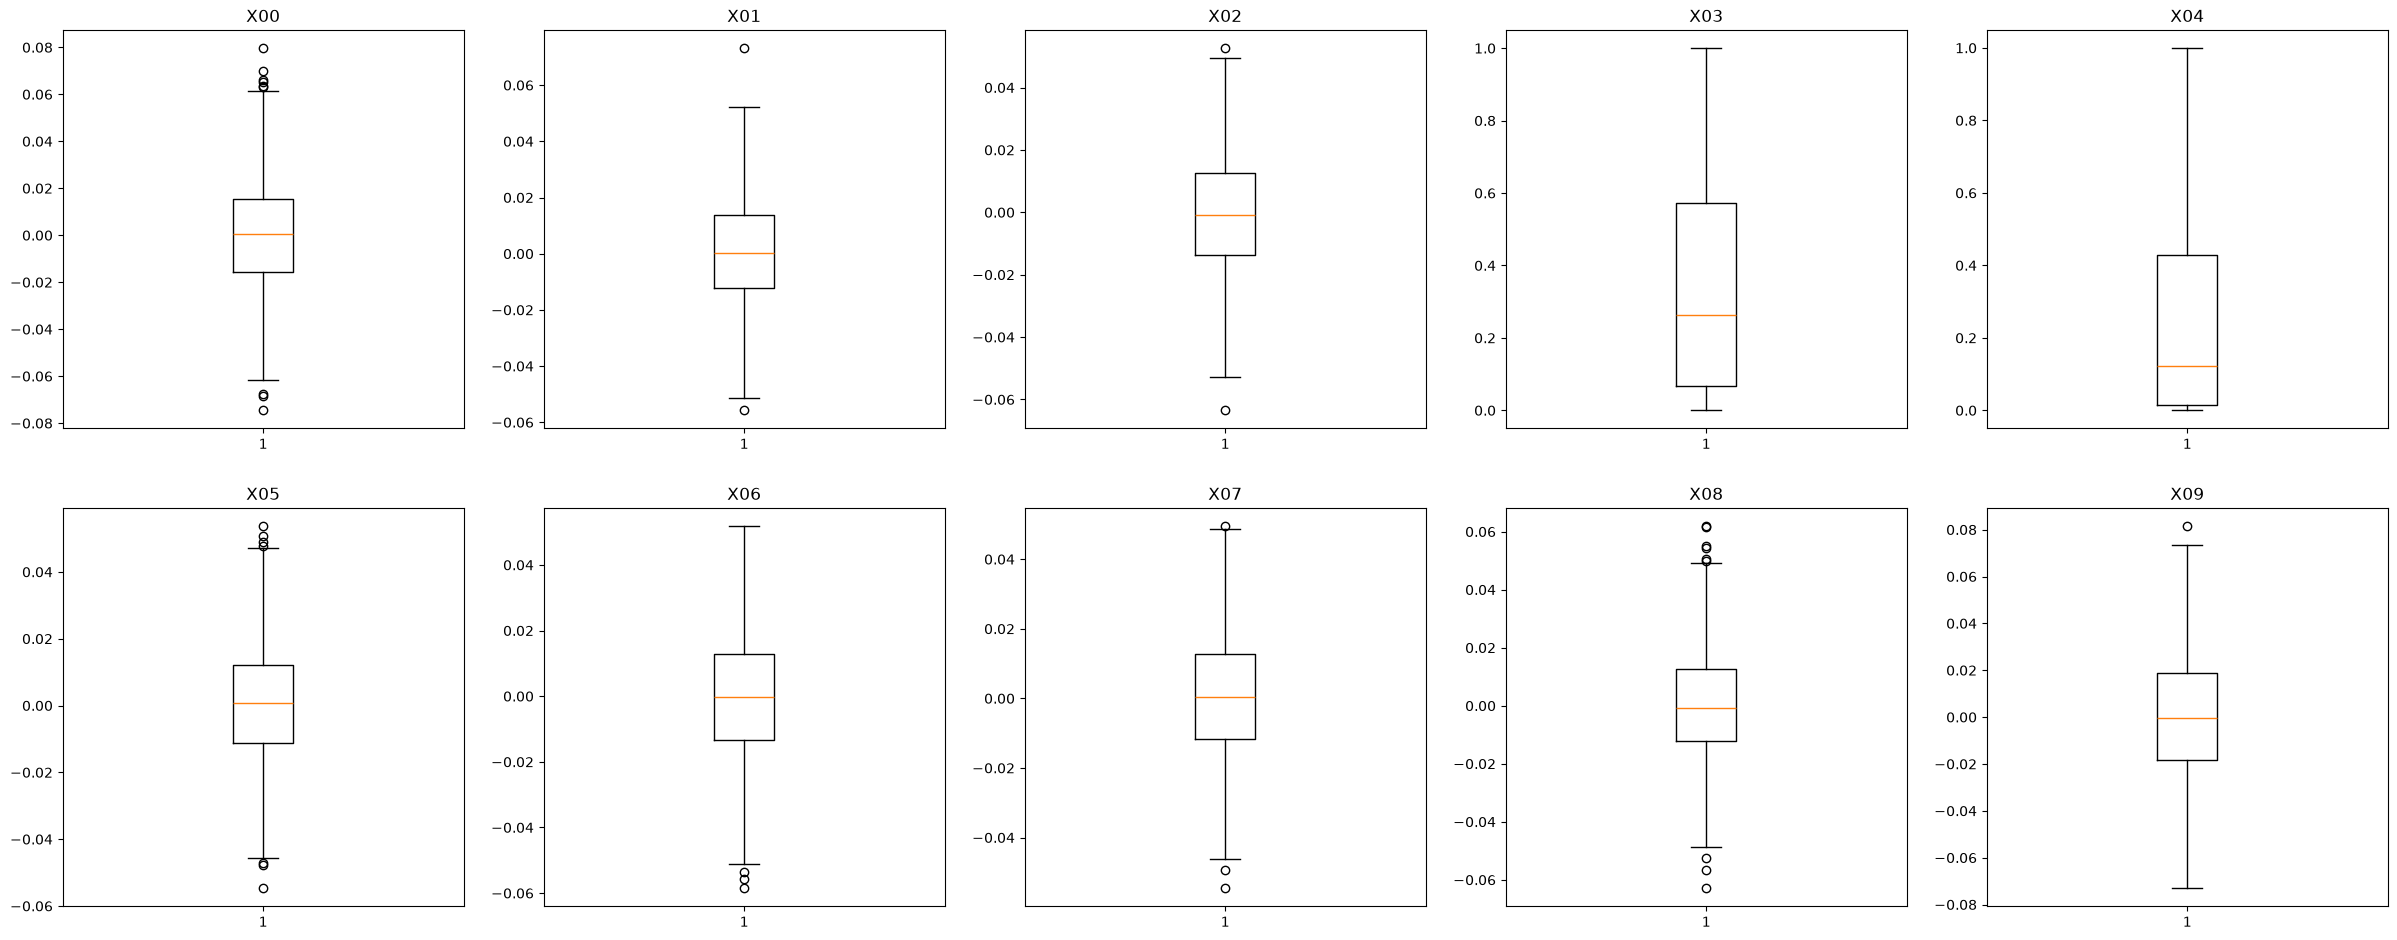

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(30,30))
for pos, col in enumerate(df.columns[:-1], start=1):
    plt.subplot(5,5,pos)
    plt.boxplot(df[col])
    plt.title(col)

plt.show()

<Axes: >

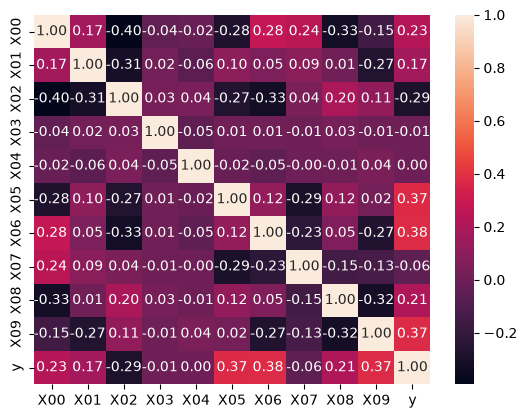

In [44]:
import seaborn as sns

sns.heatmap(df.corr(),annot=True,fmt='.2f')

# Comment the exploration of step 1 pointing out if there are predicting columns having the absolute value of correlation with the target less than 0.15 . .

X00: Values range between -0.06 and 0.06 with median around 0, box looks symmetrical with some outliers outside both fences
X01: Values range between approx. -0.05 and 0.05 with median around 0, box looks symmetrical with less outliers outside both fences	
X02, X05, X06, X07, X08, X09 are also symmetrical and around the same ranges with some outliers, some being outside both fences or one side only
X03, X04 are both right skewed and X04 more than X03, and both ranging between zero and one roughly 	


<Axes: >

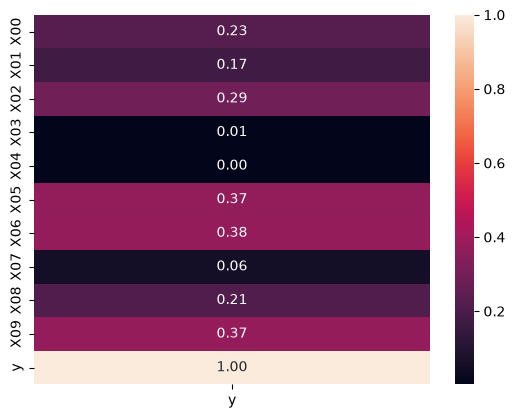

In [45]:
sns.heatmap(abs(df.corr()[['y']]),annot=True,fmt='.2f')

X03 has correlation of 0.01,X04 has correlation of 0.00, and X07 0.06 which all are very low and dont contribute to the training since they dont correlate enough with y, so they will be dropped

In [46]:
df1 = df.drop(columns = ['X03', 'X04', 'X07'])

#  train and test a multivariate linear regressor and show the Root Mean Squared Error . . 

In [47]:
from sklearn.model_selection import train_test_split
random_state=42

X = df.drop(columns=['y'])
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state)

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from math import sqrt

LR_noDrop = LinearRegression()
LR_noDrop_fitted = LR_noDrop.fit(X_train, y_train)
y_pred_train = LR_noDrop_fitted.predict(X_train)
y_pred_test = LR_noDrop_fitted.predict(X_test)


train_RMSE_noDrop = sqrt(mean_squared_error(y_train, y_pred_train))
test_RMSE_noDrop = sqrt(mean_squared_error(y_test, y_pred_test))

r2_test = LR_noDrop_fitted.score(X_test, y_test)

print("No Dropping results")
print(f"Train RMSE = {train_RMSE_noDrop:.2f}")
print(f"Test RMSE = {test_RMSE_noDrop:.2f}")
print(f"R^2 = {r2_test:.2f}")

No Dropping results
Train RMSE = 0.87
Test RMSE = 0.86
R^2 = 0.87


#  train and test a multivariate linear regressor on the reduced dataset obtained dropping the columns loosely correlated with the target, and show the Root Mean Squared Error

In [49]:
X_reduced = df1.drop(columns=['y'])
y_reduced = df1['y']

X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced, y_reduced, test_size=0.2, random_state=random_state)

In [50]:
LR_withDrop = LinearRegression()
LR_withDrop_fitted = LR_withDrop.fit(X_train_reduced,y_train_reduced)
y_pred_train_reduced = LR_withDrop_fitted.predict(X_train_reduced)
y_pred_test_reduced = LR_withDrop_fitted.predict(X_test_reduced)

train_RMSE_withDrop = sqrt(mean_squared_error(y_train_reduced, y_pred_train_reduced))
test_RMSE_withDrop = sqrt(mean_squared_error(y_test_reduced, y_pred_test_reduced))

r2_test_reduced = LR_withDrop_fitted.score(X_test_reduced,y_test_reduced)

print("With Dropping results")
print(f"Train RMSE = {train_RMSE_withDrop:.2f}")
print(f"Test RMSE = {test_RMSE_withDrop:.2f}")
print(f"R^2 = {r2_test_reduced:.2f}")

With Dropping results
Train RMSE = 1.01
Test RMSE = 0.96
R^2 = 0.84


# train and test on the reduced dataset a decision tree regressor, and show the Root Mean Squared Error . . 

In [51]:
from sklearn.tree import DecisionTreeRegressor

dtr = DecisionTreeRegressor()
dtr_fitted = dtr.fit(X_train_reduced,y_train_reduced)
y_pred_train_reduced_dtr = dtr_fitted.predict(X_train_reduced)
y_pred_test_reduced_dtr = dtr_fitted.predict(X_test_reduced)

train_dtr_rmse = sqrt(mean_squared_error(y_train_reduced, y_pred_train_reduced_dtr))
test_dtr_rmse = sqrt(mean_squared_error(y_test_reduced, y_pred_test_reduced_dtr))

r2_test_reduced_dtr = dtr_fitted.score(X_test_reduced,y_test_reduced)

print("Decision tree Regressor results")
print(f"Train RMSE = {train_dtr_rmse:.2f}")
print(f"Test RMSE = {test_dtr_rmse:.2f}")
print(f"R^2 = {r2_test_reduced_dtr:.2f}")

Decision tree Regressor results
Train RMSE = 0.00
Test RMSE = 1.76
R^2 = 0.47


# optimise the depth of the decision tree regressor of step 5 searching for the minimum Root Mean Squared Error with cross-validation, and show the best RMSE . . 

In [52]:
from sklearn.model_selection import GridSearchCV

param_grid = {'max_depth': list(range(1,11))}
dtr = DecisionTreeRegressor()
gs = GridSearchCV(estimator=dtr, param_grid=param_grid, scoring='neg_root_mean_squared_error',cv=5)
gs.fit(X_train_reduced,y_train_reduced)

print(f"Best Depth: {gs.best_params_['max_depth']}")
print(f"Best CV RMSE: {-gs.best_score_:.2f}")

Best Depth: 8
Best CV RMSE: 2.05


In [53]:
dtr_best = DecisionTreeRegressor(max_depth=gs.best_params_['max_depth'])
dtr_best_fitted = dtr_best.fit(X_train_reduced,y_train_reduced)

y_pred_dtr_best = dtr_best_fitted.predict(X_test_reduced)
dtr_best_rmse = sqrt(mean_squared_error(y_test_reduced, y_pred_dtr_best))
r2_dtr_best = dtr_best_fitted.score(X_test_reduced,y_test_reduced)

print("Optimized Decision tree Regressor results")
print(f"Test RMSE = {dtr_best_rmse:.2f}")
print(f"R^2 = {r2_dtr_best:.2f}")

Optimized Decision tree Regressor results
Test RMSE = 1.94
R^2 = 0.36


# Comment the results . . . 

**Looking at the results:**



*No Dropping results*

Train RMSE = 0.87

Test RMSE = 0.86

R² = 0.87


*With Dropping results*

Train RMSE = 1.01

Test RMSE = 0.96

R² = 0.84


*Decision tree Regressor results*

Train RMSE = 0.00

Test RMSE = 1.96

R² = 0.34


*Optimized Decision tree Regressor results*

Test RMSE = 1.93

R² = 0.36

First comparing LR with/without dropping the columns of low correlation with y, we notice that after the dropping the results are alomst the same or slightly worse which means correlation is not the only criteria that would determine of leaving or dropping columns would improve performace.
What is interesting is that the results for the DTR are worse infact the first test might indicate overfitting since the training RMSE was zero while the test was 1.96 (high capacity), All methods outperform a baseline model (R² > 0), but linear regression on the full dataset remains the best performer with R²=0.87, while the decision tree struggles with overfitting despite tuning.
